In [1]:
import random 
import numpy as np
import glob
import cv2
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import joblib

pssm_glob = 'psiblast/data/pssm/*.pssm'

In [ ]:
def read_matrix_from_pssm_file(fname):
    nrows=0
    with open(fname) as txt_file:    # Count rows.
        for line in txt_file:
            l = line.strip().split()
            if (len(l) == 44):
                nrows+=1;
    matrix = np.zeros((nrows,20), dtype="int8")
    i=0
    with open(fname) as txt_file: # Read PSSM.
        for line in txt_file:
            l = line.strip().split()
            if (len(l) == 44):
                values = np.array(list(map(int, l[2:22])))
                matrix[i,:] = values
                i+=1
    return matrix

# LOAD PSSM Matrices into protein_descriptors
protein_descritors = {}
for file in glob.glob(pssm_glob):
    pssm_matrix = read_matrix_from_pssm_file(file)
    prot_name = file.split("\\")[1].replace(".pssm", "")
    protein_descritors[prot_name] = pssm_matrix 
    
print("PSSM Matrixes read:")
print(len(protein_descritors))
#joblib.dump(protein_descritors,"protein_descritors.pkl", compress=3)

In [3]:
protein_descritors = joblib.load("protein_descritors.pkl")

In [4]:
# Create expected outputs array from sec_strucure file DSSP
dataset_file = open("sec_structs.txt", "r")
protein_secundary_structure = {}
protein_aa = {}
x = 0
name = ""
for line in dataset_file:
    if (x%4==0):
        prot_name = line.strip()
    elif(x%4==1):
        protein_aa[prot_name] = line.strip()
    elif(x%4==3):
        protein_secundary_structure[prot_name] = line.strip()
    x+=1

proteins = list(protein_secundary_structure.keys())
print(len(proteins))

1461


In [5]:
# for each proteins, for each amino extracts PSSM window with AA centered.
from scipy.ndimage import shift

X_protein_features = {}

protein_index = 0
for protein in proteins:
    pssm = protein_descritors[protein]
    protein_features = np.zeros((len(pssm),20,13))

    translated_pssm = pssm.T
    offset_start=6

    ix = 0
    for AA in range(0, len(pssm)):
        pssmmatrix = translated_pssm[:,AA+offset_start-6:AA+offset_start-6+13]
        pssmmatrix= shift(pssmmatrix, (0,offset_start), cval=0)
        if (len(pssmmatrix.T) <13):
            ncols = 13-len(pssmmatrix.T)
            aux = np.zeros((20,ncols), dtype="int8")
            pssmmatrix = np.hstack((pssmmatrix,aux))

        protein_features[ix] = pssmmatrix
       
        if (offset_start >0):
            offset_start-=1
        ix+=1
   
    X_protein_features[protein] = protein_features
    protein_index +=1

In [8]:
print(len(proteins))
#remove proteins with wrong Structural information
for prot in proteins:
    if (len(X_protein_features[prot]) != len(protein_secundary_structure[prot])):
        protein_secundary_structure.pop(prot)
    if (len(X_protein_features[prot])<30):
        protein_secundary_structure.pop(prot)
        
proteins = list(protein_secundary_structure.keys())
print(len(proteins))

1427
1427


In [24]:
proteins_subset = proteins[:100]

In [25]:
from sklearn.model_selection import train_test_split

proteins_train, proteins_test = train_test_split(proteins_subset, test_size=0.30, random_state=42)

print(len(proteins_train))
print(len(proteins_test))

70
30


In [26]:
y_train = []
for prot_name in proteins_train:
    for S in protein_secundary_structure[prot_name]:
        y_train.append(S)
print(len(y_train))

y_test = []
for prot_name in proteins_test:
    for S in protein_secundary_structure[prot_name]:
        y_test.append(S)
print(len(y_test))

X_train = np.zeros((len(y_train), 20,13))
aa_ix = 0
for prot in proteins_train:
    for AA in X_protein_features[prot]:
        X_train[aa_ix] = AA
        aa_ix += 1

X_test = np.zeros((len(y_test), 20,13))
aa_ix = 0
for prot in proteins_test:
    for AA in X_protein_features[prot]:
        X_test[aa_ix] = AA
        aa_ix += 1
        
print(X_train.shape)
print(X_test.shape)

19296
4868
(19296, 20, 13)
(4868, 20, 13)


In [27]:
ix = 0
X_one_dimensional_train = np.zeros((len(X_train),20*13))
for elem in X_train:
    X_one_dimensional_train[ix] = elem.T.ravel()
    ix+=1
ix = 0
X_one_dimensional_test = np.zeros((len(X_test),20*13))
for elem in X_test:
    X_one_dimensional_test[ix] = elem.T.ravel()
    ix+=1

In [29]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [30]:
class_ratios = {0:len(y_train[y_train==0]), 1:len(y_train[y_train==1]), 2:len(y_train[y_train==2]) }

In [31]:
print(X_one_dimensional_train.shape)
X_one_dimensional_test.shape


(19296, 260)


(4868, 260)

The best parameters are {'C': 10.0, 'gamma': 0.001} with a score of 0.86


<function matplotlib.pyplot.show(close=None, block=None)>

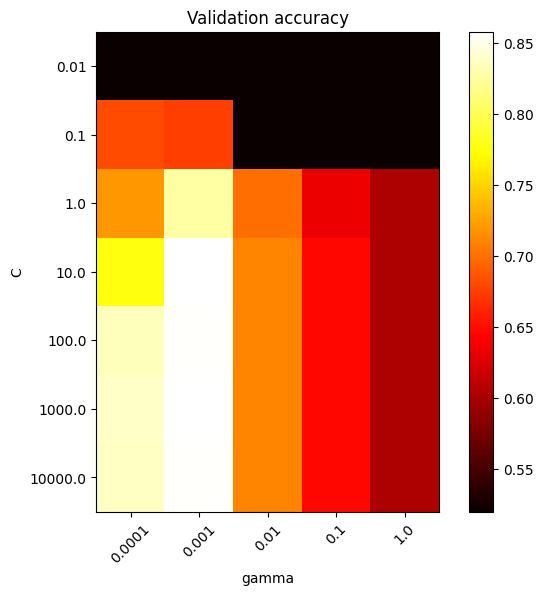

In [23]:
# Optimize parameters SVM RBF
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
import numpy as np
from matplotlib.colors import Normalize

    
C_range = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-4, 0, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), n_jobs=12, param_grid=param_grid, cv=cv)
grid.fit(X_one_dimensional_train[:], y_train[:])

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)
 
scores = grid.cv_results_["mean_test_score"].reshape(len(C_range), len(gamma_range))

plt.figure(figsize=(8, 6))
plt.subplots_adjust(left=0.2, right=0.95, bottom=0.15, top=0.95)
plt.imshow(
    scores,
    interpolation="nearest",
    cmap=plt.cm.hot,
)
plt.xlabel("gamma")
plt.ylabel("C")
plt.colorbar()
plt.xticks(np.arange(len(gamma_range)), gamma_range, rotation=45)
plt.yticks(np.arange(len(C_range)), C_range)
plt.title("Validation accuracy")
plt.show

In [32]:
from sklearn import svm
clf = svm.SVC(kernel='rbf', C= 10.0, gamma= 0.001, class_weight=class_ratios) # rbf Kernel
clf.fit(X_one_dimensional_train, y_train)
from sklearn import metrics
y_pred = clf.predict(X_one_dimensional_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred, average = 'weighted'))
print("Recall:",metrics.recall_score(y_test, y_pred, average = 'weighted'))

Accuracy: 0.747329498767461
Precision: 0.735825931409349
Recall: 0.747329498767461


In [42]:
import numpy as np

from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=None, n_clusters=4)

model = model.fit(X_one_dimensional_train)


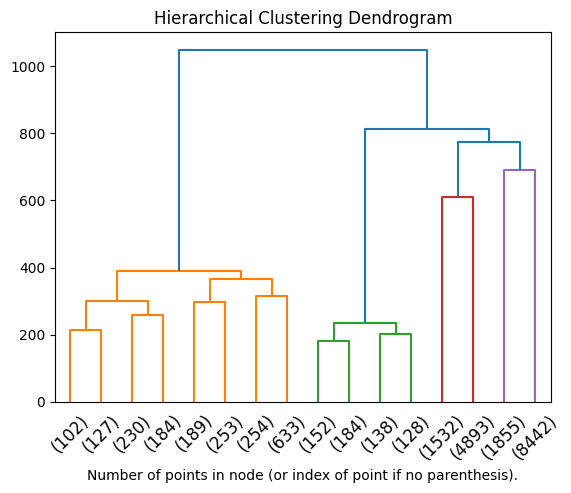

In [39]:
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.xticks(rotation = 45) # Rotates X-Axis Ticks by 45-degrees
plt.show()

In [43]:
aux = model.fit_predict(X_one_dimensional_test)

3466


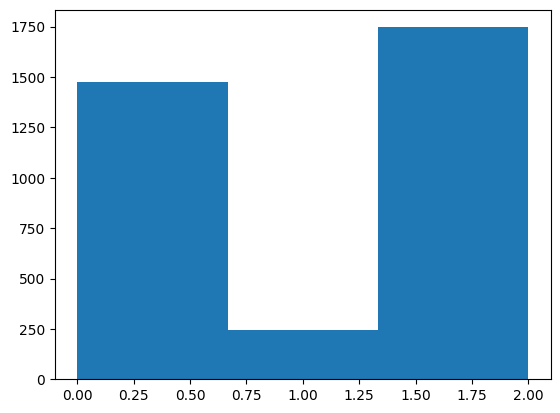

449


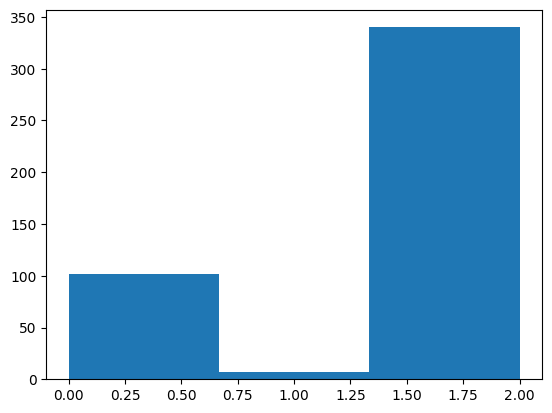

481


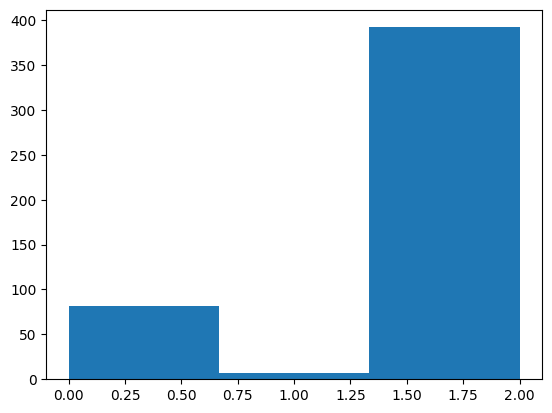

In [44]:
print(np.count_nonzero(aux==0))
y_test[aux==0]
plt.hist(y_test[aux==0],bins=3)
plt.show() 

print(np.count_nonzero(aux==1))
y_test[aux==1]
plt.hist(y_test[aux==1],bins=3)
plt.show() 

print(np.count_nonzero(aux==2))
y_test[aux==2]
plt.hist(y_test[aux==2],bins=3)
plt.show() 


Accuracy: 0.7293710328909405


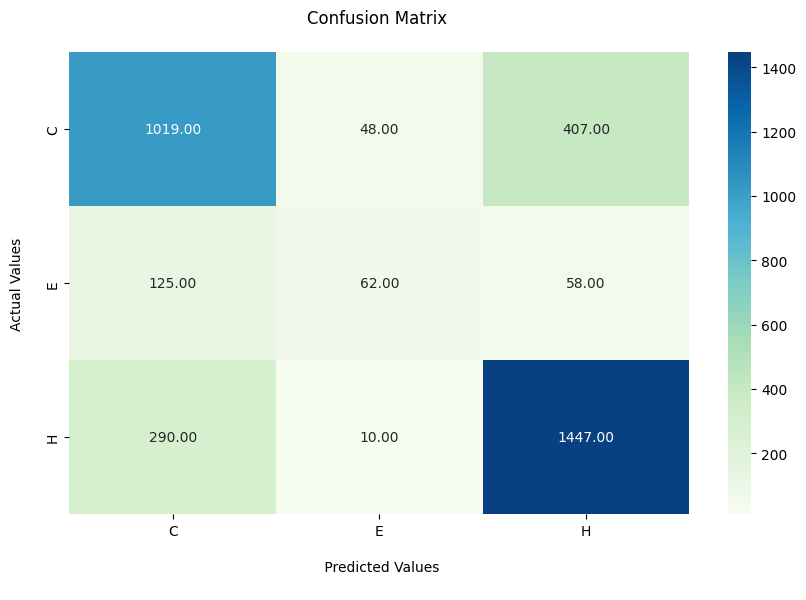

Accuracy: 0.7594654788418709


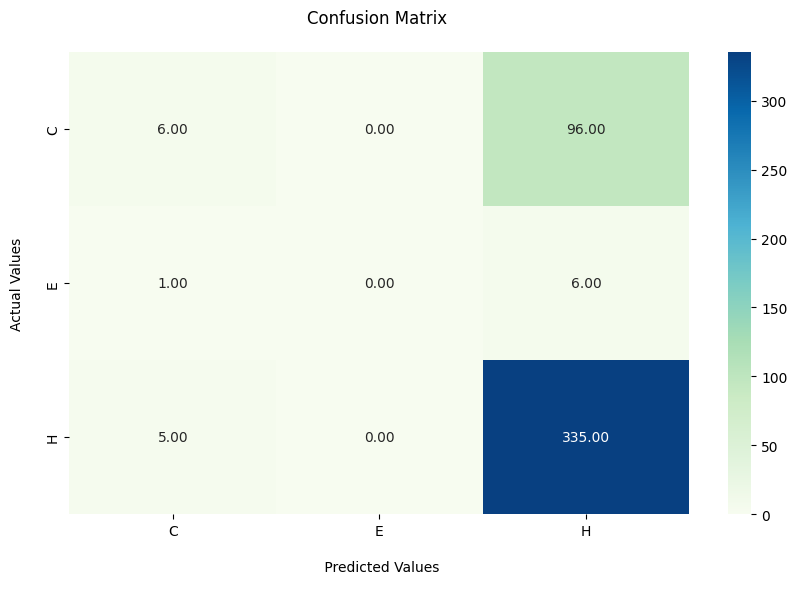

Accuracy: 0.8128898128898129


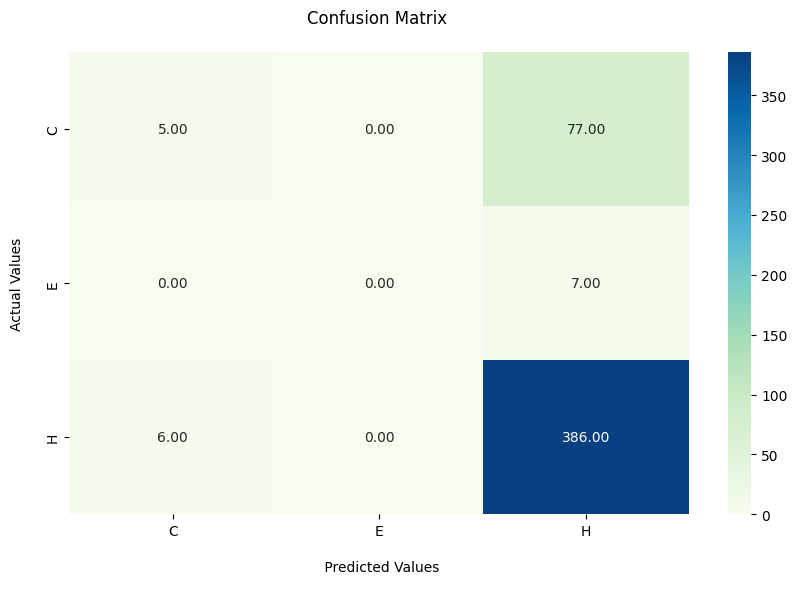

Accuracy: 0.8008474576271186


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of ticklabels (3).

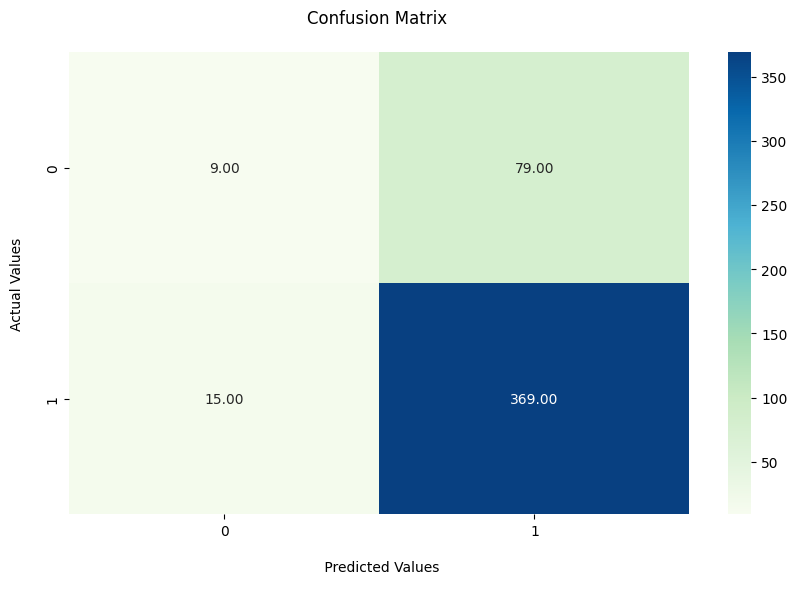

In [45]:
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = clf.predict(X_one_dimensional_test[aux==0])
print("Accuracy:",metrics.accuracy_score(y_test[aux==0], y_pred))

plt.figure(figsize=(10,6))
fx=sns.heatmap(confusion_matrix(y_test[aux==0],y_pred), annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Confusion Matrix \n');
fx.set_xlabel('\n Predicted Values\n')
fx.set_ylabel('Actual Values\n');
fx.xaxis.set_ticklabels(['C','E','H'])
fx.yaxis.set_ticklabels(['C','E','H'])
plt.show()

y_pred = clf.predict(X_one_dimensional_test[aux==1])
print("Accuracy:",metrics.accuracy_score(y_test[aux==1], y_pred))

plt.figure(figsize=(10,6))
fx=sns.heatmap(confusion_matrix(y_test[aux==1],y_pred), annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Confusion Matrix \n');
fx.set_xlabel('\n Predicted Values\n')
fx.set_ylabel('Actual Values\n');
fx.xaxis.set_ticklabels(['C','E','H'])
fx.yaxis.set_ticklabels(['C','E','H'])
plt.show()


y_pred = clf.predict(X_one_dimensional_test[aux==2])
print("Accuracy:",metrics.accuracy_score(y_test[aux==2], y_pred))

plt.figure(figsize=(10,6))
fx=sns.heatmap(confusion_matrix(y_test[aux==2],y_pred), annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Confusion Matrix \n');
fx.set_xlabel('\n Predicted Values\n')
fx.set_ylabel('Actual Values\n');
fx.xaxis.set_ticklabels(['C','E','H'])
fx.yaxis.set_ticklabels(['C','E','H'])
plt.show()


y_pred = clf.predict(X_one_dimensional_test[aux==3])
print("Accuracy:",metrics.accuracy_score(y_test[aux==3], y_pred))

plt.figure(figsize=(10,6))
fx=sns.heatmap(confusion_matrix(y_test[aux==3],y_pred), annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Confusion Matrix \n');
fx.set_xlabel('\n Predicted Values\n')
fx.set_ylabel('Actual Values\n');
fx.xaxis.set_ticklabels(['C','E','H'])
fx.yaxis.set_ticklabels(['C','E','H'])
plt.show()
